**Preparación y División de los datos**

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix

df = pd.read_csv("../../datos/procesados/abt_socios_modelo.csv")
columnas_a_eliminar = ['id_socio', 'fecha_nacimiento', 'fecha_alta', 'fecha_baja', 'tipo_cuota', 'codigo_postal']
df_ml = df.drop(columns=columnas_a_eliminar, errors='ignore')
df_ml = pd.get_dummies(df_ml, columns=['sexo', 'tipo_socio'], drop_first=True)

X = df_ml.drop('es_baja', axis=1)
y = df_ml['es_baja']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

resultados_modelos = []

print("Datos listos para entrenar. Tamaño de X_train:", X_train.shape)

Datos listos para entrenar. Tamaño de X_train: (6926, 40)


**Modelo 1: Regresión Logística**

In [31]:
from sklearn.linear_model import LogisticRegression

print("Entrenando Regresión Logística...")
modelo_lr = LogisticRegression(max_iter=5000, random_state=42)
modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)
resultados_modelos.append({
    "Modelo": "Regresión Logística",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Recall (Bajas)": recall_score(y_test, y_pred_lr),
    "F1-Score": f1_score(y_test, y_pred_lr)
})
print("Regresión Logística completada.")

Entrenando Regresión Logística...
Regresión Logística completada.


**Modelo 2: Random Forest**

In [32]:
from sklearn.ensemble import RandomForestClassifier

print("Entrenando Random Forest...")
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
resultados_modelos.append({
    "Modelo": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Recall (Bajas)": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf)
})
print("Random Forest completado.")

Entrenando Random Forest...
Random Forest completado.


**Modelo 3: XGBoost**

In [33]:
from xgboost import XGBClassifier

print("Entrenando XGBoost...")
modelo_xgb = XGBClassifier(eval_metric='logloss', random_state=42)
modelo_xgb.fit(X_train, y_train)

y_pred_xgb = modelo_xgb.predict(X_test)
resultados_modelos.append({
    "Modelo": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Recall (Bajas)": recall_score(y_test, y_pred_xgb),
    "F1-Score": f1_score(y_test, y_pred_xgb)
})
print("XGBoost completado.")

Entrenando XGBoost...
XGBoost completado.


**RESULTADOS**

In [34]:
df_resultados = pd.DataFrame(resultados_modelos).sort_values(by='Recall (Bajas)', ascending=False)
df_resultados = df_resultados.round(3)

print("TABLA DE RESULTADOS FINALES")
display(df_resultados)

TABLA DE RESULTADOS FINALES


,Modelo,Accuracy,Recall (Bajas),F1-Score
2,XGBoost,0.859,0.876,0.838
1,Random Forest,0.865,0.874,0.844
0,Regresión Logística,0.805,0.709,0.753


**Matriz de confusión**

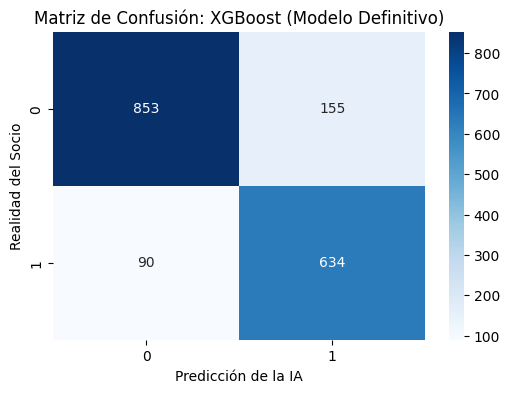

In [36]:
# Calculamos la matriz de confusión usando las predicciones del XGBoost
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

matriz = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: XGBoost (Modelo Definitivo)')
plt.xlabel('Predicción de la IA')
plt.ylabel('Realidad del Socio')
plt.show()

**Variebles más importantes**

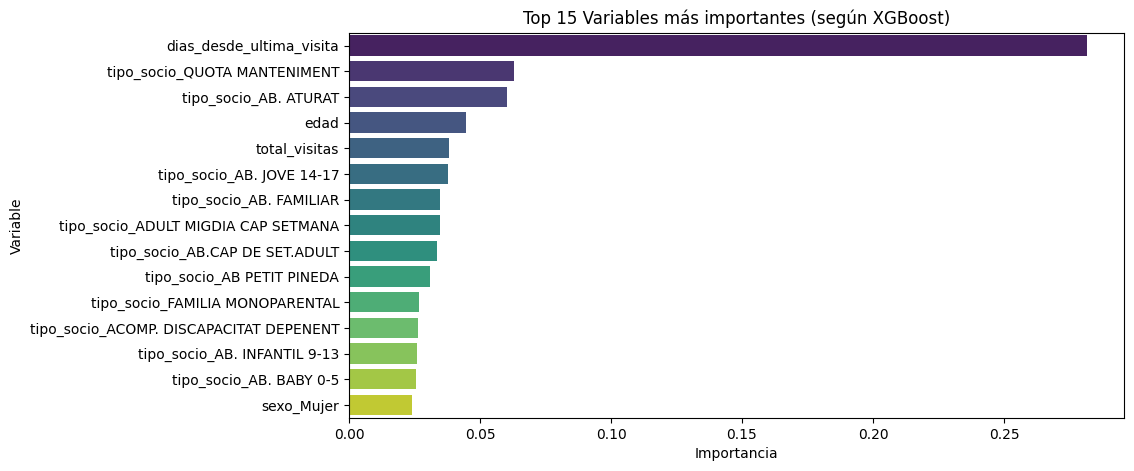

In [35]:
importancias_xgb = modelo_xgb.feature_importances_

top_15_xgb = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias_xgb
}).sort_values(by='Importancia', ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=top_15_xgb, 
    palette='viridis',
    hue='Variable',
    legend=False
)
plt.title('Top 15 Variables más importantes (según XGBoost)')
plt.show()